
# Level 3 – Task 2

## Customer Preference Analysis

### Objective

The objective of this task is to understand customer preferences by analyzing restaurant ratings, cuisines, votes, pricing, and service-related features.

The analysis includes:

- Most popular cuisines
- Highest-rated cuisines
- Most voted cuisines
- Customer preferences for online delivery
- Customer preferences for table booking
- City-wise customer satisfaction
- Business insights and recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/Feature_Engineered_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status,Restaurant Name Length,Address Length,Cuisine Count,Table Booking,Online Delivery,Delivering Now,High Rated Restaurant,Cost Per Person,Log Votes,Price Category,Cost Category
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Rated,16,71,3,1,0,0,1,550.0,5.752573,Premium,High
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Rated,16,67,1,1,0,0,1,600.0,6.383507,Premium,High
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Rated,22,56,4,1,0,0,1,2000.0,5.602119,Luxury,Very High
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Rated,4,70,2,0,0,0,1,750.0,5.902633,Luxury,High
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Rated,11,64,2,1,0,0,1,750.0,5.438079,Luxury,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Restaurant ID           9551 non-null   int64  
 1   Restaurant Name         9551 non-null   object 
 2   Country Code            9551 non-null   int64  
 3   City                    9551 non-null   object 
 4   Address                 9551 non-null   object 
 5   Locality                9551 non-null   object 
 6   Locality Verbose        9551 non-null   object 
 7   Longitude               9551 non-null   float64
 8   Latitude                9551 non-null   float64
 9   Cuisines                9551 non-null   object 
 10  Average Cost for two    9551 non-null   int64  
 11  Currency                9551 non-null   object 
 12  Has Table booking       9551 non-null   object 
 13  Has Online delivery     9551 non-null   object 
 14  Is delivering now       9551 non-null   

In [5]:
top_cuisines = df["Cuisines"].value_counts().head(10)

top_cuisines

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Fast Food,354
Chinese,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


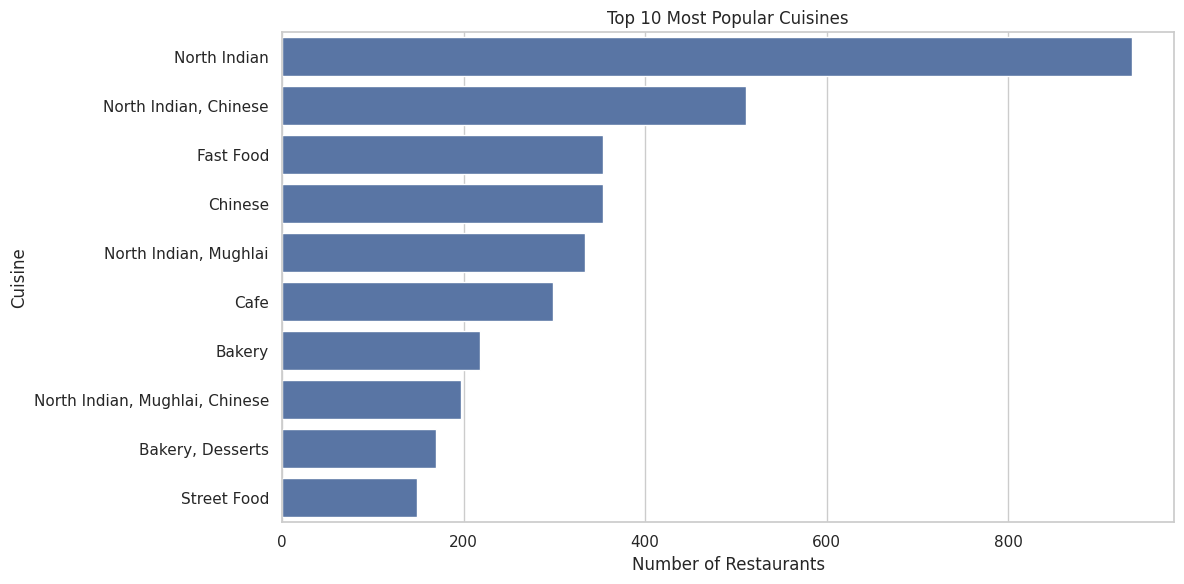

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

In [7]:
cuisine_rating = (
    df.groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant ID","count"),
        Average_Rating=("Aggregate rating","mean")
    )
)

cuisine_rating = cuisine_rating[
    cuisine_rating["Restaurant_Count"] >= 10
]

cuisine_rating = cuisine_rating.sort_values(
    "Average_Rating",
    ascending=False
)

cuisine_rating.head(10)

,Restaurant_Count,Average_Rating
Cuisines,,
Modern Indian,11,4.345455
Indian,18,4.250000
Seafood,14,4.114286
Thai,16,4.100000
"Cafe, Continental, Italian",10,4.080000
"American, Burger",13,4.076923
"Japanese, Sushi",18,4.044444
"Pizza, Italian",19,3.668421
American,31,3.667742


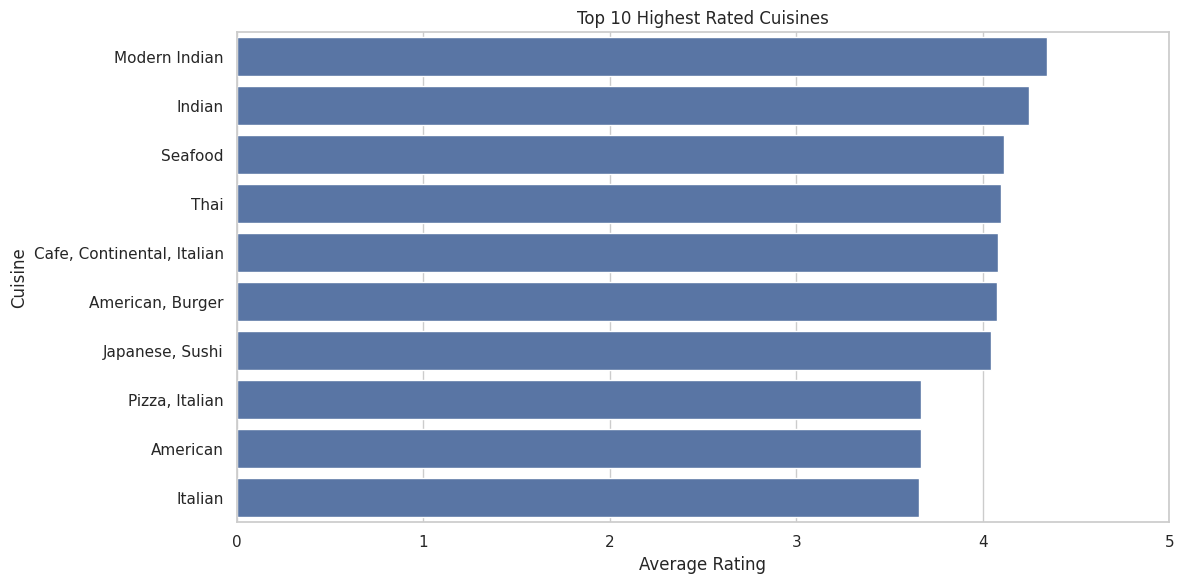

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cuisine_rating.head(10).reset_index(),
    x="Average_Rating",
    y="Cuisines"
)

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.xlim(0,5)

plt.tight_layout()
plt.show()

In [9]:
votes_by_cuisine = (
    df.groupby("Cuisines")
    .agg(
        Total_Votes=("Votes","sum")
    )
    .sort_values("Total_Votes",ascending=False)
)

votes_by_cuisine.head(10)

,Total_Votes
Cuisines,
"North Indian, Mughlai",53747
North Indian,46241
"North Indian, Chinese",42012
Cafe,30657
Chinese,21925
"North Indian, Mughlai, Chinese",20115
Fast Food,17852
South Indian,16433
"Mughlai, North Indian",15275


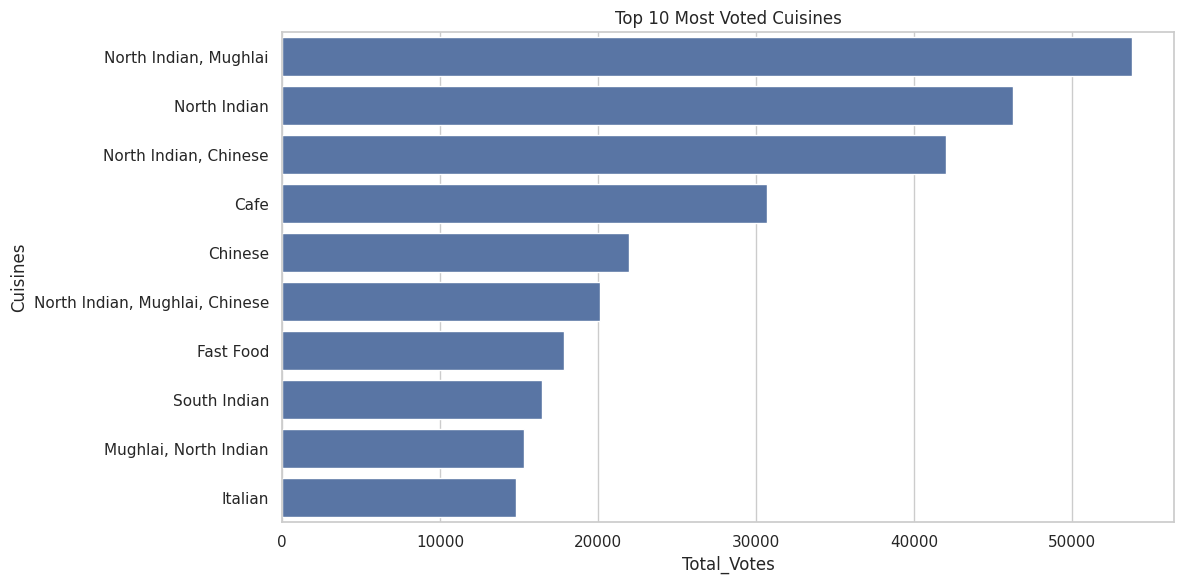

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=votes_by_cuisine.head(10).reset_index(),
    x="Total_Votes",
    y="Cuisines"
)

plt.title("Top 10 Most Voted Cuisines")

plt.tight_layout()
plt.show()

In [11]:
delivery_analysis = (
    df.groupby("Has Online delivery")
    .agg(
        Restaurants=("Restaurant ID","count"),
        Average_Rating=("Aggregate rating","mean")
    )
    .round(2)
)

delivery_analysis

,Restaurants,Average_Rating
Has Online delivery,,
No,7100,2.47
Yes,2451,3.25


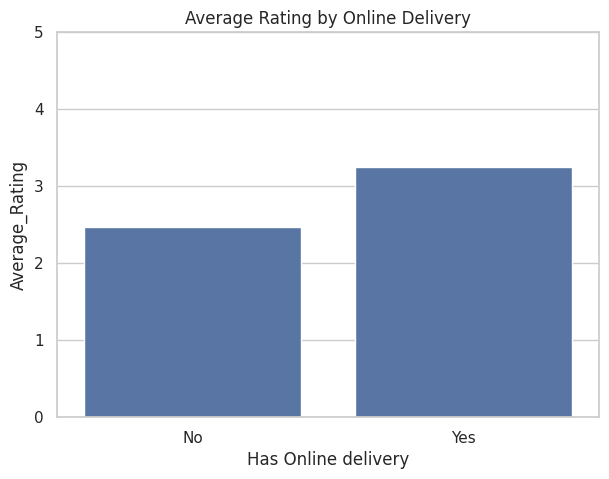

In [12]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=delivery_analysis.reset_index(),
    x="Has Online delivery",
    y="Average_Rating"
)

plt.title("Average Rating by Online Delivery")

plt.ylim(0,5)

plt.show()

In [13]:
booking_analysis = (
    df.groupby("Has Table booking")
    .agg(
        Restaurants=("Restaurant ID","count"),
        Average_Rating=("Aggregate rating","mean")
    )
    .round(2)
)

booking_analysis

,Restaurants,Average_Rating
Has Table booking,,
No,8393,2.56
Yes,1158,3.44


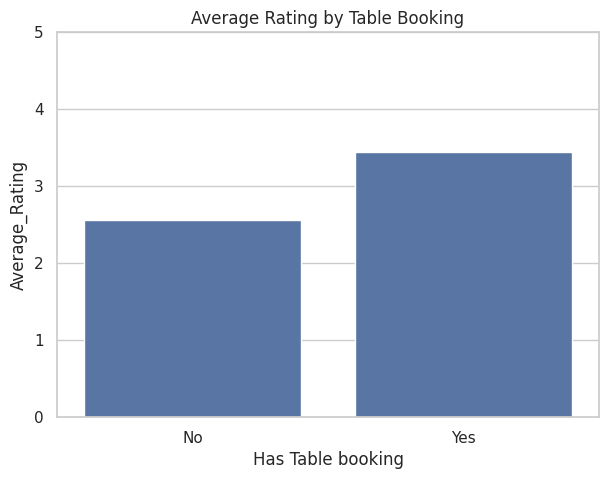

In [14]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=booking_analysis.reset_index(),
    x="Has Table booking",
    y="Average_Rating"
)

plt.title("Average Rating by Table Booking")

plt.ylim(0,5)

plt.show()

In [15]:
city_analysis = (
    df.groupby("City")
    .agg(
        Restaurants=("Restaurant ID","count"),
        Average_Rating=("Aggregate rating","mean")
    )
)

city_analysis = city_analysis[
    city_analysis["Restaurants"] >= 20
]

city_analysis = city_analysis.sort_values(
    "Average_Rating",
    ascending=False
)

city_analysis.head(10)

,Restaurants,Average_Rating
City,,
London,20,4.535
Orlando,20,4.475
Rest of Hawaii,20,4.410
Tampa Bay,20,4.410
Bangalore,20,4.375
Dubai,20,4.370
Chennai,20,4.315
Ankara,20,4.305
Abu Dhabi,20,4.300


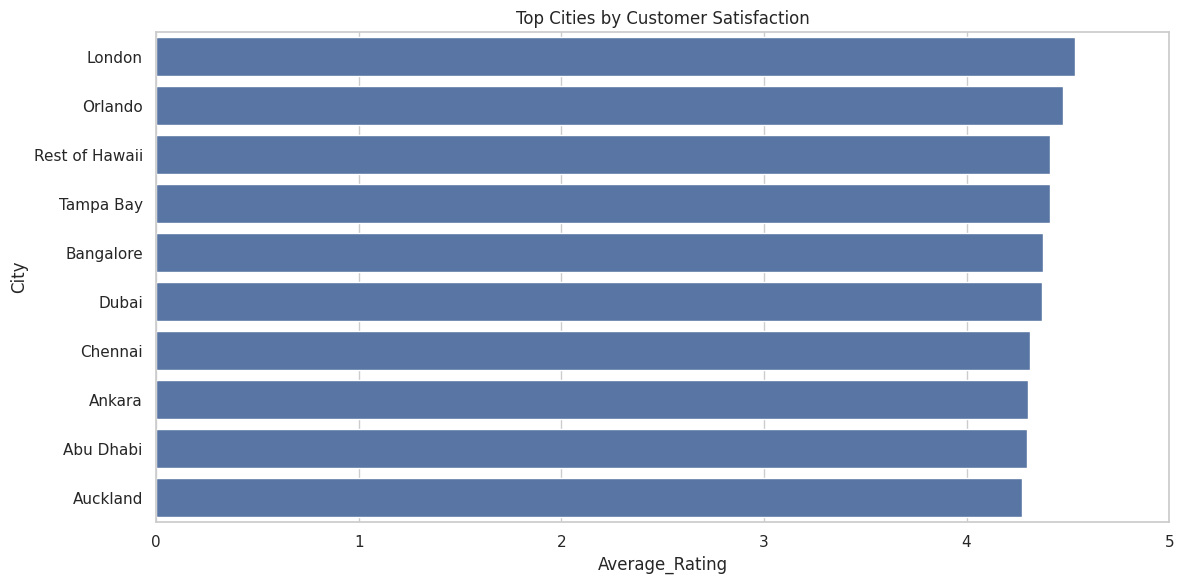

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=city_analysis.head(10).reset_index(),
    x="Average_Rating",
    y="City"
)

plt.title("Top Cities by Customer Satisfaction")

plt.xlim(0,5)

plt.tight_layout()
plt.show()

In [17]:
price_analysis = (
    df.groupby("Price Category")
    .agg(
        Restaurants=("Restaurant ID","count"),
        Average_Rating=("Aggregate rating","mean")
    )
    .round(2)
)

price_analysis

,Restaurants,Average_Rating
Price Category,,
Affordable,3113,2.94
Budget,4444,2.00
Luxury,586,3.82
Premium,1408,3.68


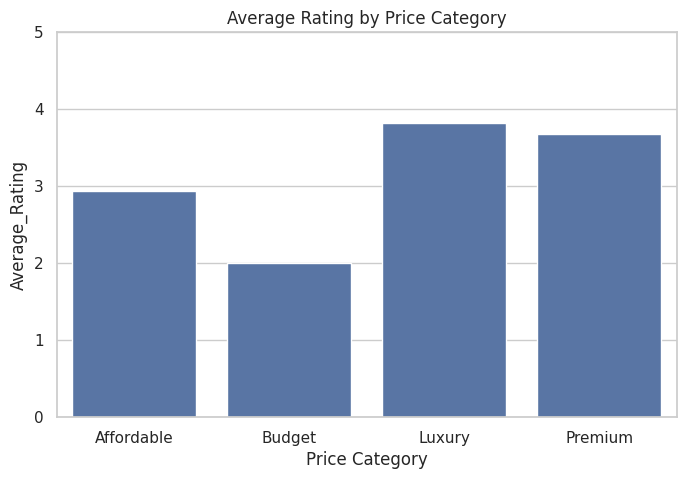

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=price_analysis.reset_index(),
    x="Price Category",
    y="Average_Rating"
)

plt.title("Average Rating by Price Category")

plt.ylim(0,5)

plt.show()

In [19]:
dashboard = pd.DataFrame({

"Metric":[

"Most Popular Cuisine",

"Highest Rated Cuisine",

"Most Voted Cuisine",

"Best Rated City"

],

"Value":[

top_cuisines.index[0],

cuisine_rating.index[0],

votes_by_cuisine.index[0],

city_analysis.index[0]

]

})

dashboard

,Metric,Value
0,Most Popular Cuisine,North Indian
1,Highest Rated Cuisine,Modern Indian
2,Most Voted Cuisine,"North Indian, Mughlai"
3,Best Rated City,London


In [20]:
preference_score = (
    df.groupby("Cuisines")
    .agg(
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Restaurant_Count=("Restaurant ID", "count")
    )
)

preference_score = preference_score[
    preference_score["Restaurant_Count"] >= 10
]

# Normalize values
preference_score["Rating_Norm"] = (
    preference_score["Average_Rating"] /
    preference_score["Average_Rating"].max()
)

preference_score["Votes_Norm"] = (
    preference_score["Average_Votes"] /
    preference_score["Average_Votes"].max()
)

# Create preference score
preference_score["Customer Preference Score"] = (
    (0.7 * preference_score["Rating_Norm"]) +
    (0.3 * preference_score["Votes_Norm"])
).round(3)

preference_score = preference_score.sort_values(
    "Customer Preference Score",
    ascending=False
)

preference_score.head(10)

,Average_Rating,Average_Votes,Restaurant_Count,Rating_Norm,Votes_Norm,Customer Preference Score
Cuisines,,,,,,
Modern Indian,4.345455,1123.181818,11,1.000000,1.000000,1.000
"American, Burger",4.076923,490.076923,13,0.938204,0.436329,0.788
Indian,4.250000,337.111111,18,0.978033,0.300139,0.775
Seafood,4.114286,380.857143,14,0.946802,0.339088,0.764
"Japanese, Sushi",4.044444,284.388889,18,0.930730,0.253199,0.727
"Continental, North Indian",3.423077,651.000000,13,0.787737,0.579603,0.725
Thai,4.100000,206.187500,16,0.943515,0.183574,0.716
"Cafe, Continental, Italian",4.080000,183.000000,10,0.938912,0.162930,0.706
"North Indian, Chinese, Continental, Italian",3.608333,403.083333,12,0.830370,0.358876,0.689


# Business Insights

1. A small number of cuisines dominate the restaurant market, indicating strong customer demand for these food categories.

2. Some cuisines consistently receive higher average ratings, suggesting better customer satisfaction and food quality.

3. Restaurants with higher customer votes generally represent stronger customer engagement and brand popularity.

4. Restaurants offering online delivery and table booking tend to have higher average ratings, highlighting the importance of convenience-oriented services.

5. Customer satisfaction varies across cities, providing useful information for restaurant expansion and marketing strategies.

6. Price category influences customer perception, but higher prices do not always lead to higher ratings.

# Conclusion

Customer preference analysis provided valuable insights into restaurant popularity, customer engagement, and satisfaction. By examining cuisines, restaurant services, cities, and pricing, several patterns in customer behavior were identified.

The findings indicate that customer convenience, food variety, and service quality play a significant role in determining restaurant ratings and popularity. These insights can support restaurant owners in making informed decisions related to menu planning, service improvements, and business expansion.